# Stochastic Gradient Descent Model for Amazon Reviews Sentiment Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import time
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

## Step 1: Data Loading and Exploration

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the balanced dataset
path = "/content/drive/MyDrive/data/raw/train.csv"
column_names = ['target', 'title_review', 'content_review']
df = pd.read_csv(path, header=None, names=column_names, dtype=str, nrows=80000)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: (80000, 3)

First few rows:
  target                                       title_review  \
0      2                     Stuning even for the non-gamer   
1      2              The best soundtrack ever to anything.   
2      2                                           Amazing!   
3      2                               Excellent Soundtrack   
4      2  Remember, Pull Your Jaw Off The Floor After He...   

                                      content_review  
0  This sound track was beautiful! It paints the ...  
1  I'm reading a lot of reviews saying that this ...  
2  This soundtrack is my favorite music of all ti...  
3  I truly like this soundtrack and I enjoy video...  
4  If you've played the game, you know how divine...  

Data types:
target            object
title_review      object
content_review    object
dtype: object

Missing values:
target            0
title_review      5
content_review    0
dtype: int64


## Step 2: Text Preprocessing Function

In [5]:
def preprocess_text(text):
    """
    Preprocess text: lowercase, remove special characters, remove stopwords, tokenize
    """
    # Convert to lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenization and stopword removal
    stop_words = set(stopwords.words('english'))
    try:
        tokens = word_tokenize(text)
        tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
        text = ' '.join(tokens)
    except:
        pass
    return text
# Test preprocessing
print("Testing preprocessing:")
sample_text = df['content_review'].iloc[0]
print(f"Original: {sample_text[:100]}")
print(f"Preprocessed: {preprocess_text(sample_text)[:100]}")

Testing preprocessing:
Original: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even t
Preprocessed: this sound track was beautiful it paints the senery in your mind so well i would recomend it even to


## Step 3: Apply Preprocessing to Dataset

In [6]:
# Combine title and content for better features
df['combined_text'] = df['title_review'].fillna('') + ' ' + df['content_review'].fillna('')
# Apply preprocessing
print("Preprocessing text data...")
df['processed_text'] = df['combined_text'].apply(preprocess_text)
# Remove empty rows after preprocessing
df = df[df['processed_text'].str.len() > 0].reset_index(drop=True)
print(f"Dataset shape after preprocessing: {df.shape}")
# Convert target to numeric
df['target'] = df['target'].astype(int)
print(f"\nClass distribution:\n{df['target'].value_counts()}")

Preprocessing text data...
Dataset shape after preprocessing: (80000, 5)

Class distribution:
target
2    41015
1    38985
Name: count, dtype: int64


## Step 4: Feature Engineering - TF-IDF Vectorization

In [7]:
# Split data first (before vectorization to avoid data leakage)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['processed_text'],
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)
print(f"Training set size: {len(X_train_text)}")
print(f"Test set size: {len(X_test_text)}")
# TF-IDF Vectorization
print("\nFitting TF-IDF Vectorizer...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    sublinear_tf=True,
    strip_accents='unicode'
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
print(f"TF-IDF feature shape: {X_train_tfidf.shape}")
print(f"Number of features extracted: {len(tfidf_vectorizer.get_feature_names_out())}")

Training set size: 64000
Test set size: 16000

Fitting TF-IDF Vectorizer...
TF-IDF feature shape: (64000, 5000)
Number of features extracted: 5000


## Step 5: Stochastic Gradient Descent Model Training

In [8]:
# Train SGD Classifier
print("Training Stochastic Gradient Descent Classifier...")
start_time = time.time()
sgd_classifier = SGDClassifier(
    loss='hinge',  # SVM loss
    penalty='l2',
    alpha=0.0001,
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    verbose=0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5
)
sgd_classifier.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.4f} seconds")

Training Stochastic Gradient Descent Classifier...
Training completed in 0.3457 seconds


## Step 6: Model Evaluation

In [9]:
# Make predictions
y_pred = sgd_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("SGD CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {training_time:.4f} seconds")

SGD CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8989
Precision: 0.8926
Recall:    0.9009
F1-Score:  0.8967
Training Time: 0.3457 seconds


## Step 7: Classification Report

In [10]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.90      0.90      7797
    Positive       0.90      0.90      0.90      8203

    accuracy                           0.90     16000
   macro avg       0.90      0.90      0.90     16000
weighted avg       0.90      0.90      0.90     16000



## Step 8: Confusion Matrix Visualization

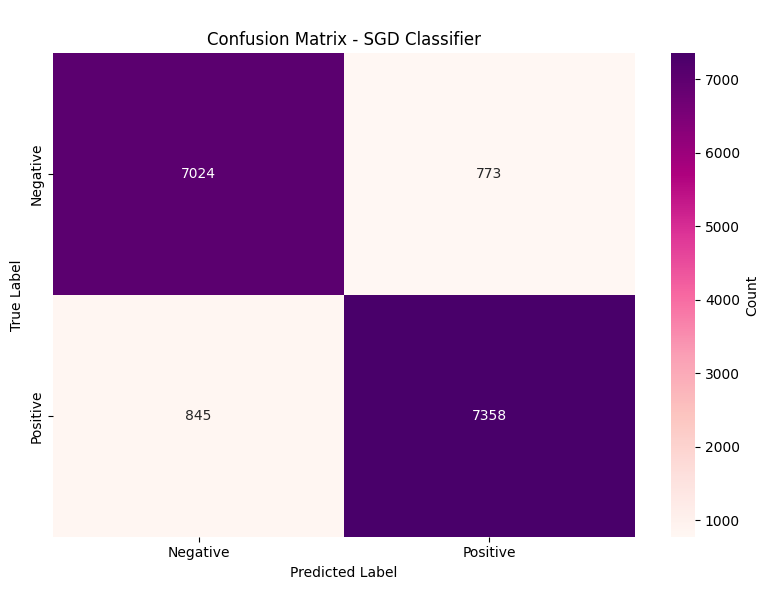

Confusion Matrix:
[[7024  773]
 [ 845 7358]]

True Negatives: 7024
False Positives: 773
False Negatives: 845
True Positives: 7358


In [11]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - SGD Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('sgd_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Step 9: Feature Coefficients (Feature Importance for Linear Models)

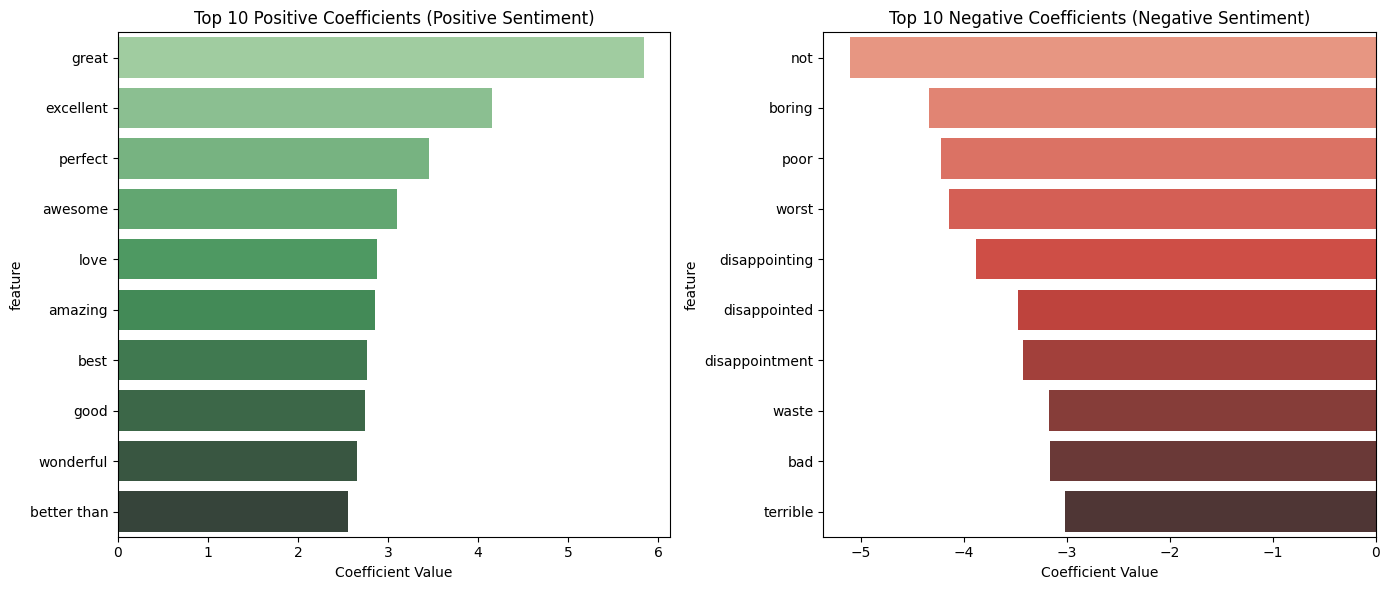


Top 10 Positive Coefficients:
    feature  coefficient
      great     5.838949
  excellent     4.152247
    perfect     3.453249
    awesome     3.096827
       love     2.872877
    amazing     2.858311
       best     2.764708
       good     2.738214
  wonderful     2.660334
better than     2.555009

Top 10 Negative Coefficients:
       feature  coefficient
           not    -5.108316
        boring    -4.339768
          poor    -4.220557
         worst    -4.148141
 disappointing    -3.879585
  disappointed    -3.475033
disappointment    -3.426947
         waste    -3.170189
           bad    -3.163860
      terrible    -3.019356


In [12]:
# Get feature coefficients
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = sgd_classifier.coef_[0]
# Create DataFrame for better visualization
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})
# Get top positive and negative features
top_positive = coef_df.nlargest(10, 'coefficient')
top_negative = coef_df.nsmallest(10, 'coefficient')
# Plot top coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_positive, x='coefficient', y='feature', palette='Greens_d', ax=axes[0])
axes[0].set_title('Top 10 Positive Coefficients (Positive Sentiment)')
axes[0].set_xlabel('Coefficient Value')
sns.barplot(data=top_negative, x='coefficient', y='feature', palette='Reds_d', ax=axes[1])
axes[1].set_title('Top 10 Negative Coefficients (Negative Sentiment)')
axes[1].set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('sgd_feature_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 10 Positive Coefficients:")
print(top_positive.to_string(index=False))
print("\nTop 10 Negative Coefficients:")
print(top_negative.to_string(index=False))

## Step 10: Model Convergence Analysis

In [13]:
# Check number of iterations
print(f"\nModel Convergence Information:")
print(f"Number of iterations: {sgd_classifier.n_iter_}")
print(f"Number of features: {sgd_classifier.n_features_in_}")
print(f"Classes: {sgd_classifier.classes_}")
print(f"Loss value: {sgd_classifier.loss}")


Model Convergence Information:
Number of iterations: 7
Number of features: 5000
Classes: [1 2]
Loss value: hinge


## Step 11: Model Summary

In [14]:
print("STOCHASTIC GRADIENT DESCENT MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Loss Function: {sgd_classifier.loss}")
print(f"  - Penalty: {sgd_classifier.penalty}")
print(f"  - Alpha (Learning Rate): {sgd_classifier.alpha}")
print(f"  - Max Iterations: {sgd_classifier.max_iter}")
print(f"  - Early Stopping: {sgd_classifier.early_stopping}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {training_time:.4f} seconds")
print(f"\nTraining Details:")
print(f"  - Iterations Required: {sgd_classifier.n_iter_}")
print(f"  - Number of Features Used: {sgd_classifier.n_features_in_}")

STOCHASTIC GRADIENT DESCENT MODEL SUMMARY

Model Parameters:
  - Loss Function: hinge
  - Penalty: l2
  - Alpha (Learning Rate): 0.0001
  - Max Iterations: 1000
  - Early Stopping: True

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8989
  - Precision: 0.8926
  - Recall:    0.9009
  - F1-Score:  0.8967
  - Training Time: 0.3457 seconds

Training Details:
  - Iterations Required: 7
  - Number of Features Used: 5000
